## 1 · Imports

In [1]:
from anndata import AnnData
from typing import Optional

# Libraries
import anndata as ad
#import matplotlib as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib.pyplot import rc_context
from scipy.stats import median_abs_deviation

from functools import partial
import altair as alt
import seaborn as sns
import decoupler as dc
from scipy.sparse import csr_matrix
import os
from pathlib import Path

import mudata as mu
import scanpy as sc
import scirpy as ir
import altair as alt
alt.data_transformers.enable("vegafusion")

import anndata as ad
import numpy as np
import palantir

import numpy as np
import scipy.sparse as sp


In [2]:
import matplotlib.pyplot as plt

In [3]:
import muon as mu
from muon import MuData

I0000 00:00:1785911875.856037  332700 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785911875.921310  332700 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785911877.701544  332700 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [4]:
from sccoda.util import cell_composition_data as dat
from sccoda.util import data_visualization as viz
#from sccoda.util import comp_ana as mod

## 2 · Data Loading

Load mudata

In [5]:
mdata = mu.read_h5mu("/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/40_gex_surface_prot/002_annotate_mudata.h5mu")

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/anndata/utils.py:354: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adop

In [6]:
mdata

MuData object with n_obs × n_vars = 72592 × 17590
  3 modalities
    gex:	72592 x 17581
      obs:	'adata_name', 'condition', 'batch_id', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'rna_leiden', 'rna_leiden_05', 'gex03', 'group4', 'cell_annotation_05'
      var:	'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells'
      uns:	'cell_annotation_05_colors', 'gex03', 'gex03_colors', 'group4_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'rna_leiden', 'rna_leiden_05', 'rna_leiden_05_colors', 'rna_leiden_colors', 'sample_id_colors', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    adt:	56305 x 9
      obs:	'sample_id', 'year', 'tissue', 'treatment', 'received_ici'
    airr:	56305 x 0
      obs:	'sample_id'
      obsm:	'airr'

In [9]:
mdata["gex"].obs.group4.unique()

['ctrl', 'effector', 'GF_noici', 'GF']
Categories (4, object): ['effector' < 'ctrl' < 'GF' < 'GF_noici']

In [11]:
import numpy as np

# 1. Target the AnnData object (or mdata["gex"])
adata = mdata["gex"]  # adjust variable name if working on an independent adata

# 2. Extract expression values for both genes
ifng_expr = adata[:, "Ifng"].X
cxcr3_expr = adata[:, "Cxcr3"].X
mki67_expr = adata[:, "Mki67"].X

# Handle sparse matrix format if necessary
if hasattr(ifng_expr, "toarray"):
    ifng_expr = ifng_expr.toarray().flatten()
    cxcr3_expr = cxcr3_expr.toarray().flatten()
    mki67_expr = mki67_expr.toarray().flatten()
else:
    ifng_expr = ifng_expr.flatten()
    cxcr3_expr = cxcr3_expr.flatten()
    mki67_expr = mki67_expr.flatten()

# 3. Create boolean mask for double-positive cells (Ifng > 0 AND Cxcr3 > 0)
triple_pos_mask = (ifng_expr > 0) & (cxcr3_expr > 0) & (mki67_expr > 0)

# 4. Subset the AnnData object (.copy() creates a clean independent object)
adata_ifng_cxcr3_mki67 = adata[triple_pos_mask].copy()

# Summary output
print(f"Total cells before filtering: {adata.n_obs}")
print(f"Triple positive (Ifng+ Cxcr3+) cells: {adata_ifng_cxcr3_mki67.n_obs}")

Total cells before filtering: 72592
Triple positive (Ifng+ Cxcr3+) cells: 639


In [12]:
import numpy as np

# 1. Target the GEX layer to extract gene expression
gex = mdata["gex"]

# 2. Extract expression values for both genes
ifng_expr = gex[:, "Ifng"].X
cxcr3_expr = gex[:, "Cxcr3"].X
mki67_expr = gex[:, "Mki67"].X

# Handle sparse matrix format if necessary
if hasattr(ifng_expr, "toarray"):
    ifng_expr = ifng_expr.toarray().flatten()
    cxcr3_expr = cxcr3_expr.toarray().flatten()
    mki67_expr = mki67_expr.toarray().flatten()
else:
    ifng_expr = ifng_expr.flatten()
    cxcr3_expr = cxcr3_expr.flatten()
    mki67_expr = mki67_expr.toarray()

# 3. Create boolean mask for double-positive cells (Ifng > 0 AND Cxcr3 > 0)
triple_pos_mask = (ifng_expr > 0) & (cxcr3_expr > 0) & (mki67_expr > 0)

# 4. Subset the ENTIRE MuData object directly
# This automatically subsets both mdata["gex"] AND mdata["airr"] in sync
mdata_ifng_cxcr3_mki67 = mdata[double_pos_mask].copy()

# 5. (Optional) Update internal MuData metadata synchronization
mdata_ifng_cxcr3_mki67.update()

# Summary output
print(f"Total cells before filtering: {mdata.n_obs}")
print(
    f"Triple positive (Ifng+ Cxcr3+) cells: {mdata_ifng_cxcr3_mki67.n_obs}"
)
print(f"GEX layer shape: {mdata_ifng_cxcr3_mki67['gex'].shape}")
print(f"AIRR layer shape: {mdata_ifng_cxcr3_mki67['airr'].shape}")

Total cells before filtering: 72592
Triple positive (Ifng+ Cxcr3+) cells: 4141
GEX layer shape: (4141, 17581)
AIRR layer shape: (3083, 0)


/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: Fro

In [13]:
ir.pp.index_chains(mdata_ifng_cxcr3_mki67)

In [14]:
ir.tl.chain_qc(mdata_ifng_cxcr3_mki67)

... storing 'airr:receptor_type' as categorical
... storing 'airr:receptor_subtype' as categorical
... storing 'airr:chain_pairing' as categorical
... storing 'gex:gene_ids' as categorical
... storing 'receptor_type' as categorical
... storing 'receptor_subtype' as categorical
... storing 'chain_pairing' as categorical


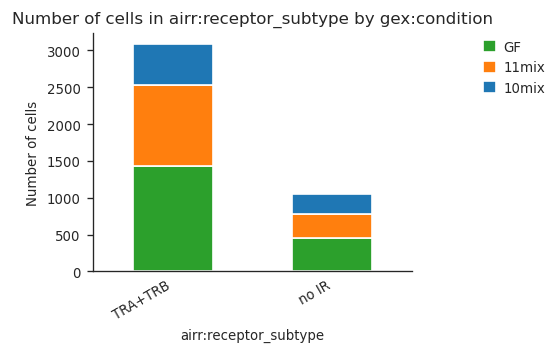

In [15]:
_ = ir.pl.group_abundance(mdata_ifng_cxcr3_mki67, groupby="airr:receptor_subtype", target_col="gex:condition")

In [16]:
mu.pp.filter_obs(mdata_ifng_cxcr3_mki67, "airr:chain_pairing", lambda x: x != "multichain")

In [17]:
mu.pp.filter_obs(mdata_ifng_cxcr3_mki67, "airr:chain_pairing", lambda x: ~np.isin(x, ["orphan VDJ", "orphan VJ"]))

In [18]:
# using default parameters, `ir_dist` will compute nucleotide sequence identity
ir.pp.ir_dist(mdata_ifng_cxcr3_mki67)
ir.tl.define_clonotypes(mdata_ifng_cxcr3_mki67, receptor_arms="all", dual_ir="primary_only")

In [19]:
ir.tl.clonal_expansion(mdata_ifng_cxcr3_mki67)

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/scirpy/util/__init__.py:458: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return 1 / cast(np.ndarray, obs.groupby(normalize_col)[normalize_col].transform("count").values)


<Axes: >

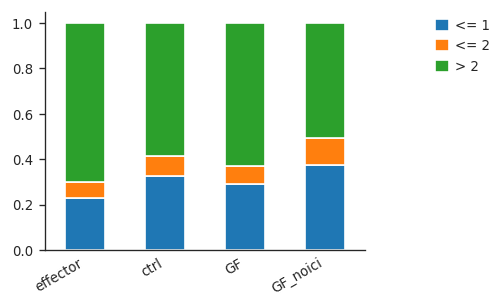

In [21]:
ir.pl.clonal_expansion(mdata_ifng_cxcr3_mki67, target_col="clone_id", groupby="gex:group4")

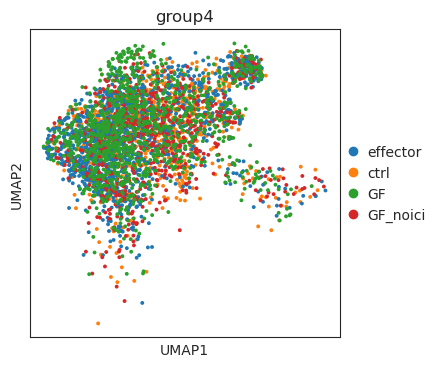

In [23]:
sc.pl.umap(mdata_ifng_cxcr3_mki67["gex"], color = "group4")

<Axes: title={'center': 'cell_annotation_05'}, xlabel='UMAP1', ylabel='UMAP2'>

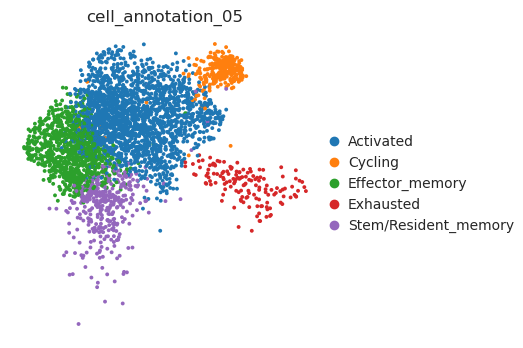

In [25]:
sc.pl.umap(
    mdata_ifng_cxcr3_mki67["gex"],
    color=["cell_annotation_05"],
    cmap="Reds",
    vmin=0,
    vmax="p99",
    sort_order=False,
    show=False, frameon=False
)

In [26]:
sc.tl.rank_genes_groups(mdata_ifng_cxcr3_mki67["gex"], "group4", method="wilcoxon")

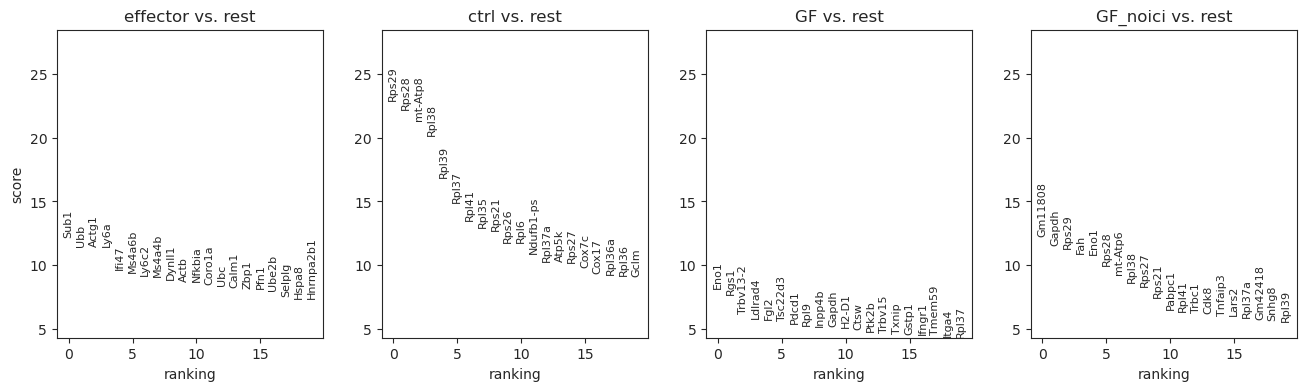

In [27]:
sc.pl.rank_genes_groups(mdata_ifng_cxcr3_mki67["gex"])

In [ ]:
sc.pl.dotplot(
    mdata_ifng_cxcr3_mki67["gex"],
    var_names=var_names,
    groupby="group4",
    standard_scale="var",  # Scales gene expression between 0 and 1 across groups
    dendrogram=True,  # Optional: clusters groups by similarity
)

## 2 · Compositional  


In [31]:
sample_col = "sample_id"
cluster_col = "cell_annotation_05"   # or "rna_leiden", "gex03"
condition_col = "group4"

In [32]:
cov_df = (
    mdata_ifng_cxcr3_mki67["gex"].obs[[sample_col, condition_col]]
    .drop_duplicates()
    .set_index(sample_col)
)

cov_df

,group4
sample_id,
10mix_ICI1,ctrl
10mix_ICI2,ctrl
11mix_ICI1,effector
11mix_ICI2,effector
GF_ICI1,GF_noici
GF_ICI2,GF_noici
GF_ICI1_plus,GF
GF_ICI2_plus,GF


In [33]:
cov_df = (
    mdata_ifng_cxcr3_mki67["gex"].obs[[sample_col, condition_col]]
    .drop_duplicates()
    .set_index(sample_col)
)

In [35]:
sccoda_data = dat.from_scanpy(
    mdata_ifng_cxcr3_mki67["gex"],
    cell_type_identifier=cluster_col,
    sample_identifier=sample_col,
    covariate_df=cov_df
)

sccoda_data

AnnData object with n_obs × n_vars = 8 × 5
    obs: 'group4'
    var: 'n_cells'

In [36]:
import pandas as pd

condition_col = "group4"

desired_order = [
"GF_noici",
    "GF",
    "ctrl",
    "effector"
]

# Set ordered categories
sccoda_data.obs[condition_col] = pd.Categorical(
    sccoda_data.obs[condition_col],
    categories=desired_order,
    ordered=True
)

# Optional: sort rows by category order
sccoda_data.obs = sccoda_data.obs.sort_values(condition_col)

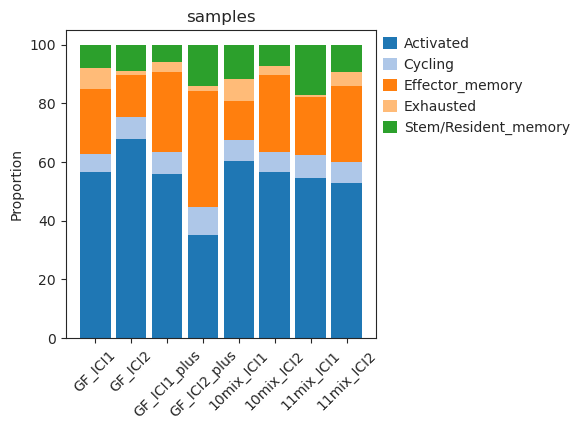

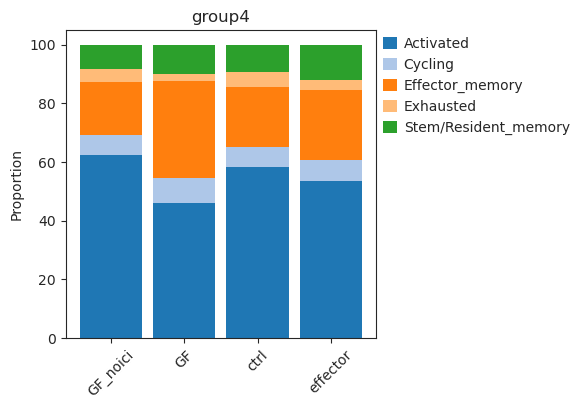

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/seaborn/axisgrid.py:85

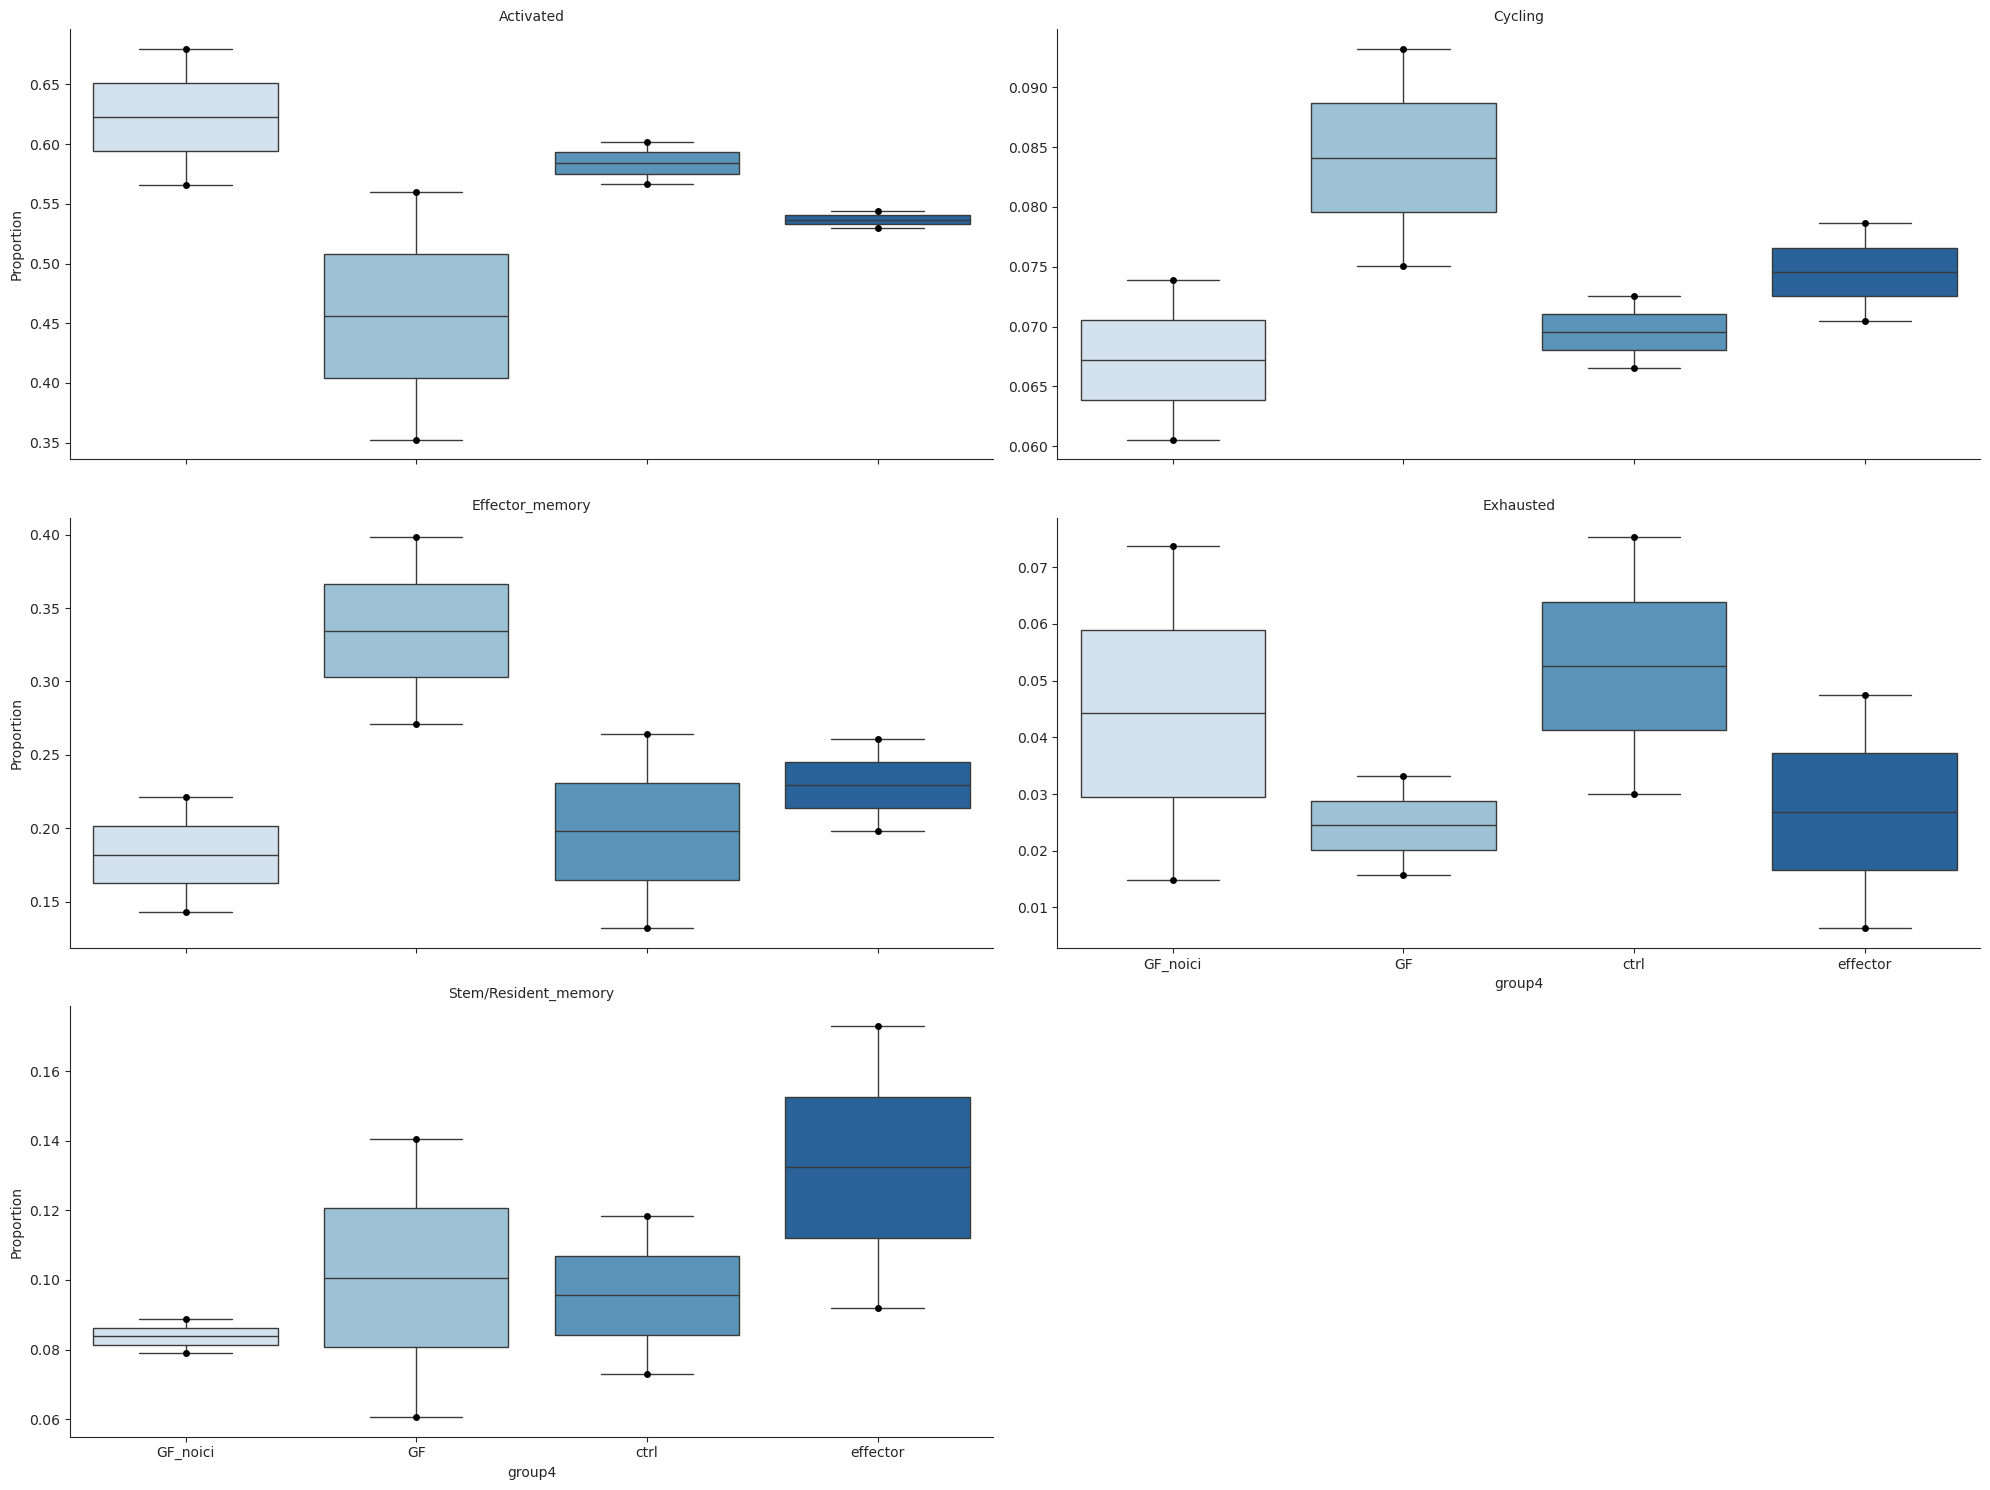

In [37]:
viz.stacked_barplot(sccoda_data, feature_name="samples")
plt.show()

viz.stacked_barplot(sccoda_data, feature_name=condition_col)
plt.show()

viz.boxplots(
    sccoda_data,
    feature_name=condition_col,
    plot_facets=True,
    y_scale="relative",
    add_dots=True
)
plt.show()

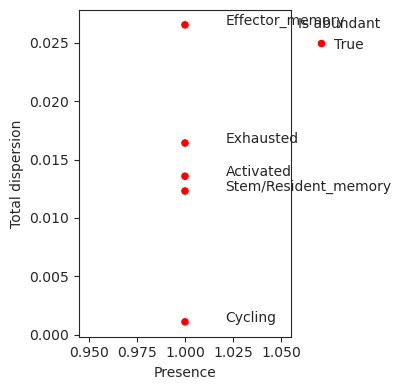

In [38]:
viz.rel_abundance_dispersion_plot(
    data=sccoda_data,
    abundant_threshold=0.9
)
plt.show()

## Running the model 

In [39]:
sccoda_data.var

,n_cells
cell_annotation_05,
Activated,2086
Cycling,290
Effector_memory,976
Exhausted,140
Stem/Resident_memory,386


In [53]:
GF_noici.obs.sample_id

AAACGGGCAAGGTTCT-1_10mix1    ctrl1
AAAGATGAGATCCCAT-1_10mix1    ctrl1
AACACGTAGTACGACG-1_10mix1    ctrl1
AACCATGCACCCTATC-1_10mix1    ctrl1
AACGTTGTCGTAGGAG-1_10mix1    ctrl1
                             ...  
GGCTCGAAGACACTAA-1_GF2         GF2
GTCGGGTTCTTGTCAT-1_GF2         GF2
GTTTCTATCCCATTTA-1_GF2         GF2
TAAGTGCGTGAGCGAT-1_GF2         GF2
TCAGCTCGTAGCGATG-1_GF2         GF2
Name: sample_id, Length: 808, dtype: category
Categories (6, object): ['GF1', 'GF2', 'ctrl1', 'ctrl2', 'effector1', 'effector2']

In [45]:
import pandas as pd

obs =mdata_ifng_cxcr3_mki67["gex"].obs.copy()

cell_counts = (
    pd.crosstab(
        obs["sample_id"],
        obs["cell_annotation_05"]
    )
    .reset_index()
)

cell_counts = cell_counts.rename(columns={"sample_id": "Mouse"})

cell_counts

cell_annotation_05,Mouse,Activated,Cycling,Effector_memory,Exhausted,Stem/Resident_memory
0,10mix_ICI1,215,23,84,28,30
1,10mix_ICI2,276,30,58,6,36
2,11mix_ICI1,388,52,188,23,42
3,11mix_ICI2,223,59,252,10,89
4,GF_ICI1,224,27,49,28,44
5,GF_ICI1_plus,264,31,123,14,34
6,GF_ICI2,173,25,63,2,55
7,GF_ICI2_plus,323,43,159,29,56


In [46]:
sample_order = ["GF_ICI2_plus","GF_ICI1_plus",
    "GF_ICI1", "GF_ICI2",
    "10mix_ICI1", "10mix_ICI2",
    "11mix_ICI2", "11mix_ICI1",

]

cell_counts["Mouse"] = pd.Categorical(
    cell_counts["Mouse"],
    categories=sample_order,
    ordered=True
)

cell_counts = (
    cell_counts
    .sort_values("Mouse")
    .reset_index(drop=True)
)

In [47]:
cell_counts

cell_annotation_05,Mouse,Activated,Cycling,Effector_memory,Exhausted,Stem/Resident_memory
0,GF_ICI2_plus,323,43,159,29,56
1,GF_ICI1_plus,264,31,123,14,34
2,GF_ICI1,224,27,49,28,44
3,GF_ICI2,173,25,63,2,55
4,10mix_ICI1,215,23,84,28,30
5,10mix_ICI2,276,30,58,6,36
6,11mix_ICI2,223,59,252,10,89
7,11mix_ICI1,388,52,188,23,42


In [48]:
# Convert data to anndata object
data_all = dat.from_pandas(cell_counts, covariate_columns=["Mouse"])

# Extract condition from mouse name and add it as an extra column to the covariates
data_all.obs["Condition"] =  (data_all.obs["Mouse"].str.replace(r"\d+$", "", regex=True))

In [49]:
data_all.obs

cell_annotation_05,Mouse,Condition
0,GF_ICI2_plus,GF_ICI2_plus
1,GF_ICI1_plus,GF_ICI1_plus
2,GF_ICI1,GF_ICI
3,GF_ICI2,GF_ICI
4,10mix_ICI1,10mix_ICI
5,10mix_ICI2,10mix_ICI
6,11mix_ICI2,11mix_ICI
7,11mix_ICI1,11mix_ICI


In [51]:
# Select control and salmonella data
data_cd8 = data_all[data_all.obs["Condition"].isin(["11mix_ICI", "10mix_ICI"])]
print(data_cd8.obs)

cell_annotation_05       Mouse  Condition
4                   10mix_ICI1  10mix_ICI
5                   10mix_ICI2  10mix_ICI
6                   11mix_ICI2  11mix_ICI
7                   11mix_ICI1  11mix_ICI


/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/sccoda/util/data_visualization.py:335: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cell_types, rotation=90)


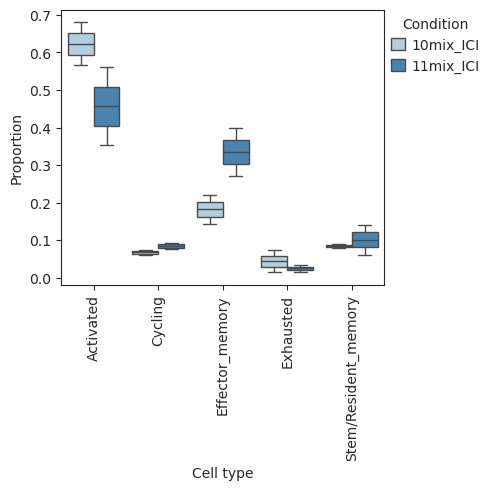

In [52]:
viz.boxplots(data_cd8, feature_name="Condition",figsize=(5,5))
plt.show()

In [53]:

from sccoda.util import comp_ana as mod

2026-08-05 08:48:23 | [INFO] arviz_base not installed
2026-08-05 08:48:23 | [INFO] arviz_stats not installed
2026-08-05 08:48:23 | [INFO] arviz_plots not installed
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [56]:
model_salm = mod.CompositionalAnalysis(data_cd8, formula="Condition", reference_cell_type="Cycling")

In [57]:
# Run MCMC
sim_results = model_salm.sample_hmc()

100%|██████████| 20000/20000 [01:55<00:00, 173.55it/s]


MCMC sampling finished. (146.596 sec)
Acceptance rate: 50.7%


In [58]:
sim_results.summary()

Compositional Analysis summary:

Data: 4 samples, 5 cell types
Reference index: 1
Formula: Condition

Intercepts:
                      Final Parameter  Expected Sample
Cell Type                                             
Activated                       3.347       308.888692
Cycling                         1.346        41.761756
Effector_memory                 2.326       111.272371
Exhausted                       0.525        18.374815
Stem/Resident_memory            1.479        47.702366


Effects:
                                             Final Parameter  Expected Sample  \
Covariate              Cell Type                                                
Condition[T.11mix_ICI] Activated                         0.0       308.888692   
                       Cycling                           0.0        41.761756   
                       Effector_memory                   0.0       111.272371   
                       Exhausted                         0.0        18.374815   
    

In [59]:
print(sim_results.credible_effects())

Covariate               Cell Type           
Condition[T.11mix_ICI]  Activated               False
                        Cycling                 False
                        Effector_memory         False
                        Exhausted               False
                        Stem/Resident_memory    False
Name: Final Parameter, dtype: bool


In [35]:
import pickle as pkl

In [ ]:
# saving
#outdir = "/data/scratch/kvalem/projects/2021/honda_microbial_metabolites_2021/20_scripts/40_single-cell-sorted-cd8/40_gex_surface_prot/28012026/results/sccoda/sccoda_model_normal"

#sim_results.save(outdir)

# loading
#with open(outdir, "rb") as f:
#    sim_results_2 = pkl.load(f)

#sim_results_2.summary()